<a href="https://colab.research.google.com/github/marynatarasevych/ML_Study/blob/main/Tarasevych_%22HW_2_1_%D0%9F%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B0_%D0%BB%D1%96%D0%BD%D1%96%D0%B9%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97_%D0%B7%D0%B0_%D0%BE%D0%B4%D0%BD%D0%BE%D1%8E_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D1%8E_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', lambda x: f'{x:,.2f}'.replace(',', ' '))

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
medical_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Hanna Pylieva/Модулі/Модуль 2 Лінійна регресія/Модуль 2. Лінійна регресія - Дата/Medical Charges.csv")

In [50]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16 884.92
1,18,male,33.77,1,no,southeast,1 725.55
2,28,male,33.00,3,no,southeast,4 449.46
3,33,male,22.70,0,no,northwest,21 984.47
4,32,male,28.88,0,no,northwest,3 866.86


In [51]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [52]:
X = non_smoker_df.age
y = non_smoker_df.charges

**Метод МНК (з використанням тільки numpy, без scikit learn)**

In [53]:
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [54]:
X_MNK = np.c_[np.ones((X.shape[0], 1)), X]

In [55]:
MNK_coefs = normal_equations(X_MNK, y)
MNK_coefs

array([-2091.42055657,   267.24891283])

In [56]:
predictions_MNK = np.dot(X_MNK, MNK_coefs)

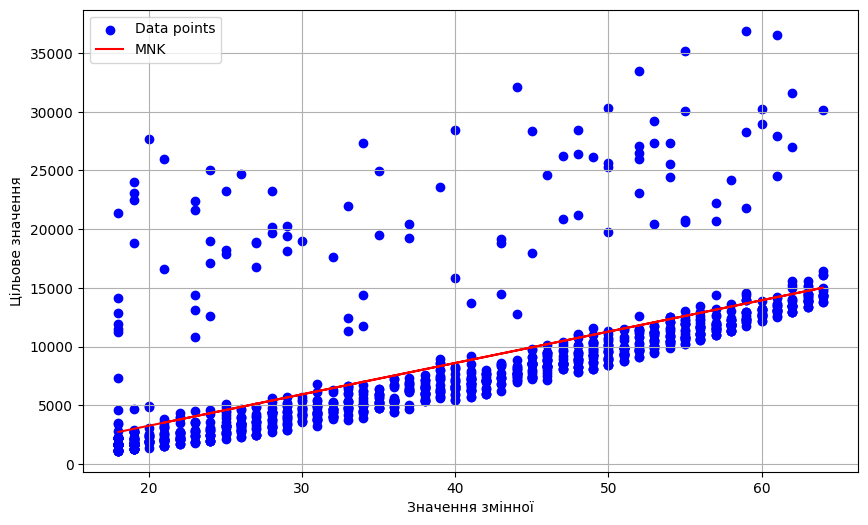

In [57]:
# Візуалізація результатів
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_MNK, color='red', label='MNK')
plt.xlabel('Значення змінної')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [58]:
from sklearn.metrics import root_mean_squared_error
rmse_MNK = root_mean_squared_error(y, predictions_MNK)
print(f"rmse_MNK: {rmse_MNK:.2f}")

rmse_MNK: 4662.51


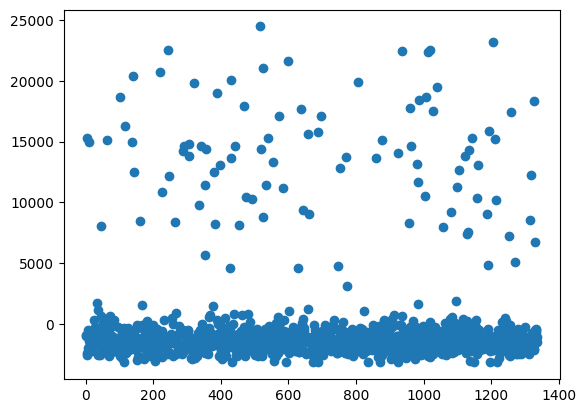

In [59]:
errors_MNK = y - predictions_MNK
plt.plot(errors_MNK, 'o');

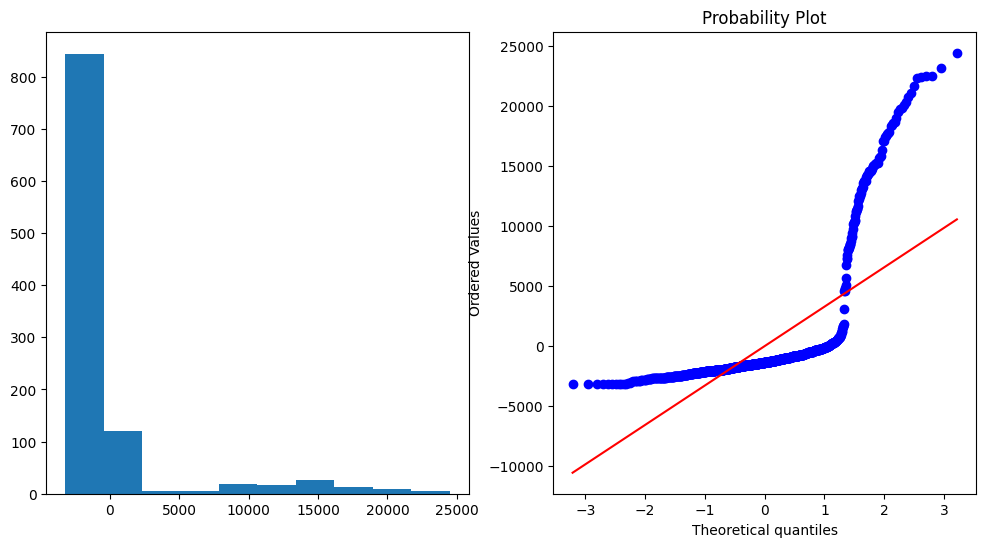

In [60]:
from scipy.stats import probplot

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(errors_MNK)
plt.subplot(1,2,2)
probplot(errors_MNK, dist='norm', plot=plt);

**Full-Batch градієнтного спуску з numpy**

In [61]:
X_gd = X.values.reshape(-1, 1)

In [62]:
# Градієнтний спуск
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(sum(error**2)) # сума помилок в квадраті
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

In [63]:
for lr in [0.01, 0.001, 0.0001]:
    m, b, errors = full_batch_gradient_descent(X_gd, y, lr=lr, epochs=1000)
    print(f"lr={lr}: m={m}, b={b}, остання помилка={errors[-1]}")

/tmp/ipykernel_18853/4068746268.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


lr=0.01: m=nan, b=-inf, остання помилка=nan
lr=0.001: m=nan, b=inf, остання помилка=nan
lr=0.0001: m=221.1045843794301, b=-41.98126853149978, остання помилка=23636496769.69646


In [64]:
m, b, errors_fbgd = full_batch_gradient_descent(X_gd, y, lr=0.0001, epochs=1000)
predictions_fbgd = m * X_gd[:, 0] + b

m, b

(np.float64(221.1045843794301), np.float64(-41.98126853149978))

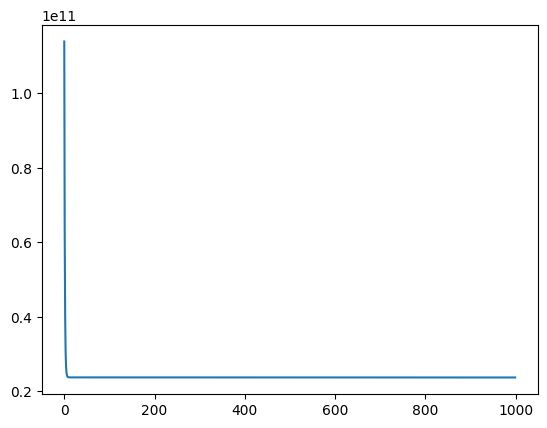

In [90]:
plt.plot(errors_fbgd);

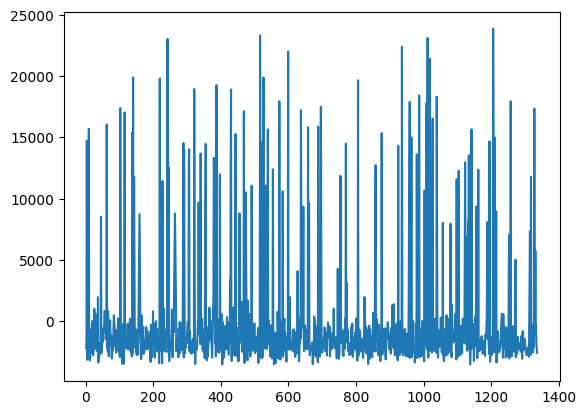

In [88]:
errors_fbgd_1 = y - predictions_fbgd
plt.plot(errors_fbgd_1);

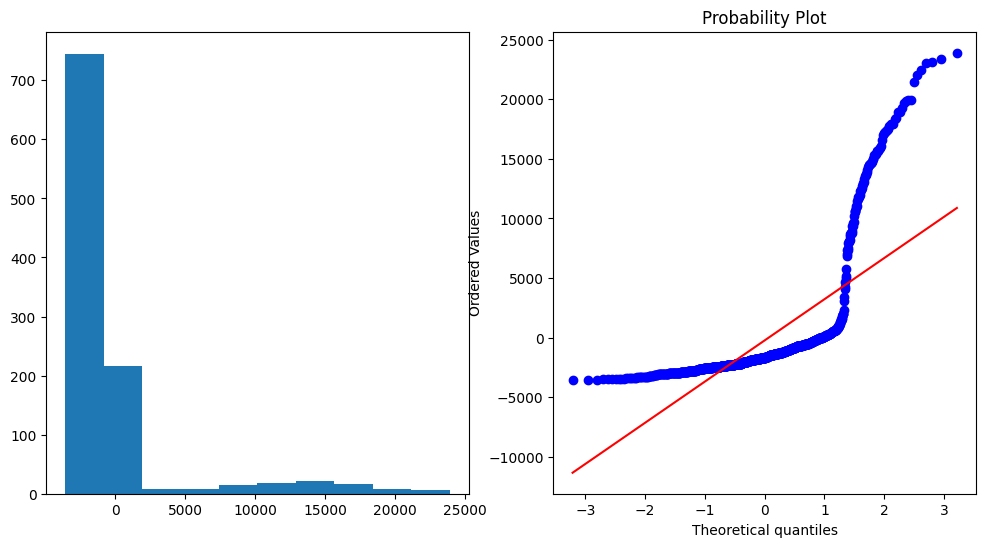

In [89]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(errors_fbgd_1)
plt.subplot(1,2,2)
probplot(errors_fbgd_1, dist='norm', plot=plt);

In [67]:
rmse_fbgd = root_mean_squared_error(y, predictions_fbgd)
print(f"rmse_fbgd: {rmse_fbgd:.2f}")

rmse_fbgd: 4713.25


**З scikit-learn.LinearRegression.** Тут зверніть увагу, що вхід X має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись X.to_frame() щоб конвертувати колонку в датафрейм

In [68]:
from sklearn.linear_model import LinearRegression

In [69]:
lin_reg = LinearRegression()

In [70]:
X_sklearn = X.values.reshape(-1, 1)

In [71]:
lin_reg.fit(X_sklearn, y)

LinearRegression()

In [72]:
lin_reg.coef_, lin_reg.intercept_

(array([267.24891283]), np.float64(-2091.4205565650864))

In [73]:
predictions_sklearn = lin_reg.predict(X_sklearn)

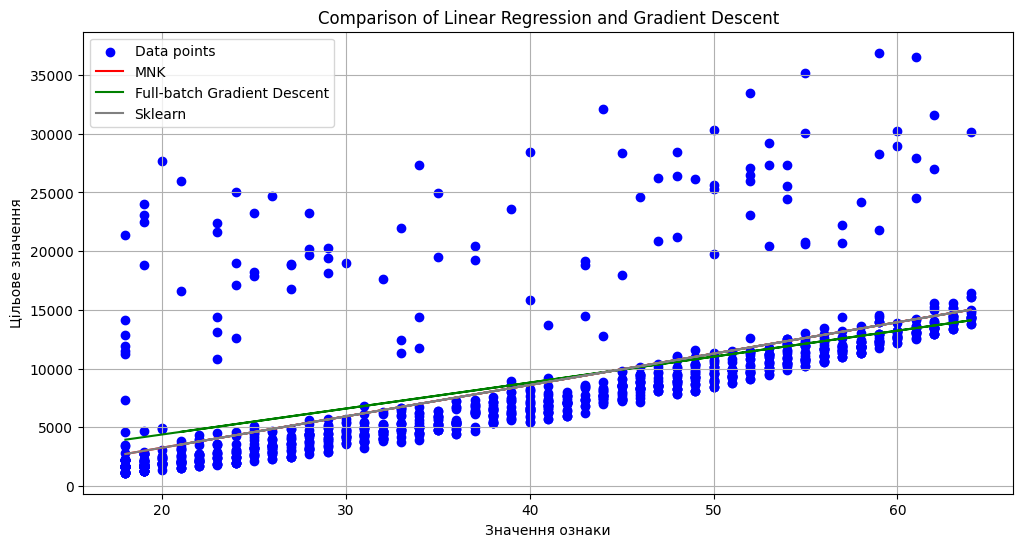

In [74]:
# Візуалізація результатів
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_MNK, color='red', label='MNK')
plt.plot(X, predictions_fbgd, color='green', label='Full-batch Gradient Descent')
plt.plot(X, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

In [75]:
rmse_sklearn = root_mean_squared_error(y, predictions_sklearn)
print(f"rmse_sklearn: {rmse_sklearn:.2f}")

rmse_sklearn: 4662.51


In [76]:
from sklearn.metrics import r2_score

r2_MNK = r2_score(y, predictions_MNK)
r2_fbgd = r2_score(y, predictions_fbgd)
r2_sklearn = r2_score(y, predictions_sklearn)

In [78]:
print('Коефіцієнти з МНК: ', MNK_coefs, 'RSME з МНК: ', rmse_MNK, 'R2 з МНК: ', r2_MNK)
print('Коефіцієнти з град. спуску: ', b, m, 'RSME з град. спуску: ', rmse_fbgd, 'R2 з град. спуску: ', r2_fbgd)
print('Коефіцієнти з sklearn: ', lin_reg.intercept_, lin_reg.coef_, 'RSME з sklearn: ', rmse_sklearn, 'R2 з sklearn: ', r2_sklearn)

Коефіцієнти з МНК:  [-2091.42055657   267.24891283] RSME з МНК:  4662.505766636395 R2 з МНК:  0.3943171632425906
Коефіцієнти з град. спуску:  -41.98126853149978 221.1045843794301 RSME з град. спуску:  4713.250582815521 R2 з град. спуску:  0.3810614072961034
Коефіцієнти з sklearn:  -2091.4205565650864 [267.24891283] RSME з sklearn:  4662.505766636395 R2 з sklearn:  0.3943171632425906


**Висновки**

1. Метод МNК - дав RMSE 4663 (R2 = 0.394). З графіку розподілу помилок errors_MNK видно, що він не схожий на нормальний і графік QQ-plot також це підтверджує.

Це значить, що змінна `age` хоч і впливає на `charges`, але не може лінійно достовірно спрогнозувати це значення. Згідно графіку розподілу фактичних `charges` з спрогнозованою. лінією, є багато точок в верхній частині графіку, які і заважають спрогнощзувати достовірне значення

2. Full-Batch градієнтного спуску - спробувала 3 різні lr: 0.01, 0.001, 0.0001. На перші 2 градфєнтний спуск не зійшовся, а на 3 - так. Проте 1000 epochs виявилось замало для прогнозування наближеної до MNK лінійної регресії (коеф. -41 і +221, а в МNК -2091 і +267 --> градієнтний спуск не встиг за 1000 ітерацій спуститись на рівень -2091 і залишився на рівні -41).
Графік помилки в залежності від ітерації показує, що помилка різко падає в перші 10-20 epochs, а всі інші до 1000 не дали ефект.

Графіку розподілу помилок (не піднесений до квадрату) - так само як і в Методі МNК, не має нормального розподілу, тобто не може спрогнозувати ефективно `charges` за змінною `age`

RMSE =  4713 (R2 = 0.381).
Цей метод трохи гірше підібрав коефіцієнти, ніж Метод МNК

3.  scikit-learn.LinearRegression.
Самі розрахунки вопторюють метод МNК і мають такі самі висновки

Знайдені параметри хоч і є близькими до мої найкращих припущень, але через низький R2, не можуть бути використані для моделі. Скоріш за все, потрібно шукати інші змінні для лінійної регресії.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [94]:
smoker_df = medical_df[medical_df.smoker == 'yes']
X_s = smoker_df.age.to_frame()
y_s = smoker_df.charges

In [95]:
lin_reg_smoker = LinearRegression()

In [96]:
lin_reg_smoker.fit(X_s, y_s)

LinearRegression()

In [98]:
lin_reg_smoker.coef_, lin_reg.intercept_

(array([305.23760211]), np.float64(20294.128126915966))

In [99]:
predictions_smoker = lin_reg.predict(X_s)

In [100]:
r2 = r2_score(y_s, predictions_smoker)
rmse = root_mean_squared_error(y_s, predictions_smoker)
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"Коефіцієнти: intercept={lin_reg_smoker.intercept_:.2f}, slope={lin_reg_smoker.coef_[0]:.2f}")

R²: 0.1356
RMSE: 10711.00
Коефіцієнти: intercept=20294.13, slope=305.24


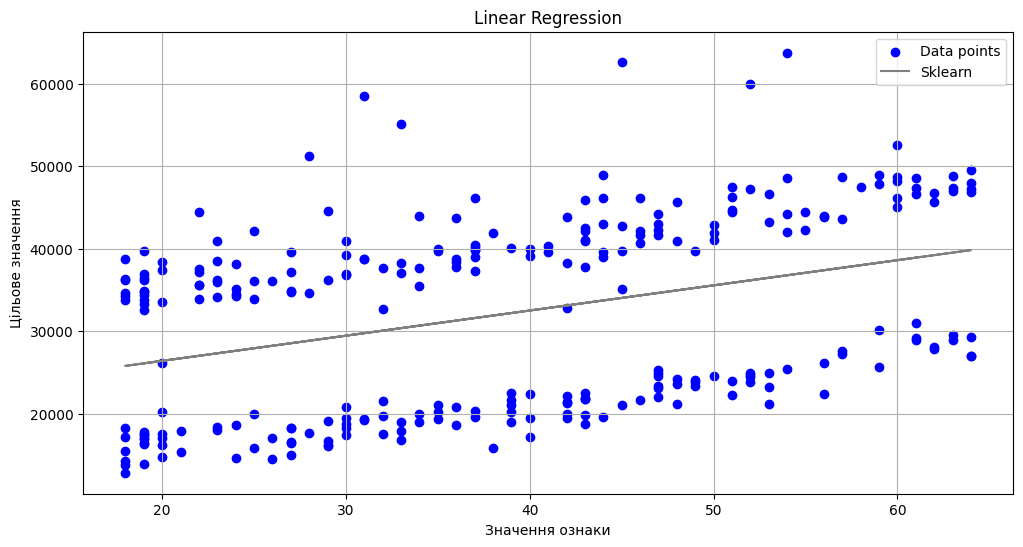

In [101]:
plt.figure(figsize=(12, 6))
plt.scatter(X_s, y_s, color='blue', label='Data points')
plt.plot(X_s, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Linear Regression')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

**Висновок**

Лінійна регресія тільки за змінною `age` по курцям не описує розподіл фактичних даних, а лежить між ними. Самі дані розділені на дві групи - зверхк гряфіку і знизу графіку. Скоріш за все, тут є залежність ще з якимось фактором, наприклад BMI.

R2 для такої моделі мійже дорівнює 0 і значить, що така модель не може спрогнозувати `chardes` для курців

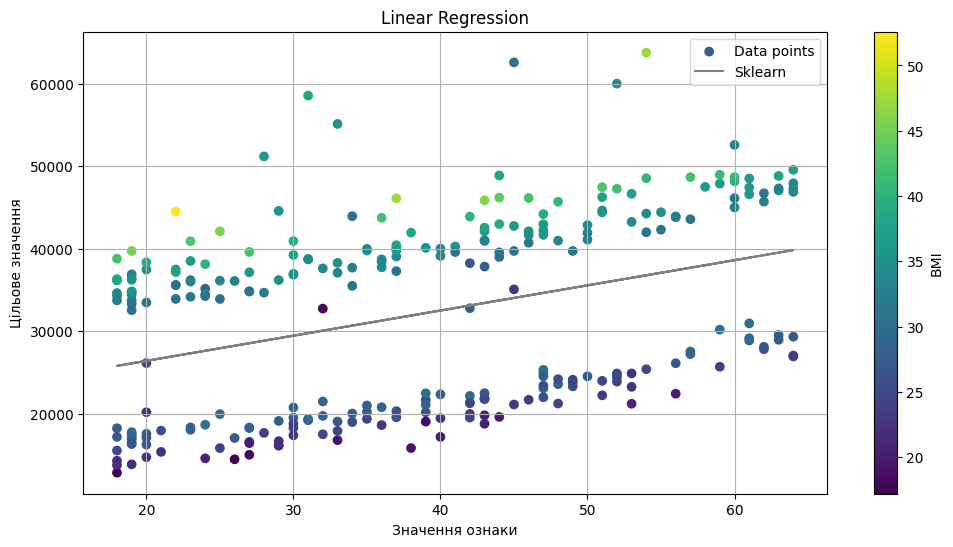

In [105]:
plt.figure(figsize=(12, 6))
plt.scatter(X_s, y_s, c=smoker_df.bmi, label='Data points', cmap='viridis')
plt.colorbar(label='BMI')
plt.plot(X_s, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Linear Regression')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Для курців, сума `charges` ще залежить від BMI - чим вищий BMI , тим вищий  `charges`. Необхідно врахувати це в моделі для курців